Name: Ashish Ranjan
Application No.: IN26012845
Email-id: ashish138169@gmail.com

# Real-Time Card-Not-Present Fraud Detection
**Domain:** FinTech / E-Commerce Payments  
**Algorithm Focus:** Support Vector Machines (SVM)  
**Dataset:** [Credit Card Fraud Detection (ULB Machine Learning Group)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

## Executive Summary
This project builds a robust classification engine to detect fraudulent credit card transactions. Due to the extreme class imbalance inherent in fraud detection, standard accuracy metrics are highly misleading. This notebook explores data separability, applies rigorous scaling, and utilizes Stratified Cross-Validation to evaluate Support Vector Machine (SVM) configurations, optimizing for Precision-Recall Area Under the Curve (PR-AUC) to minimize the operational costs of false positives and false negatives.

In [3]:
import sys
print(sys.executable)

d:\CardNotPresentFraudDetection\.venv\Scripts\python.exe


In [3]:
# Standard Data Manipulation
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure presentation-ready visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
warnings.filterwarnings('ignore')

print("Environment successfully initialized.")

Environment successfully initialized.


## 1. Data Loading and Structural Inspection
The dataset contains 28 anonymized numerical features resulting from a PCA transformation (V1-V28), plus `Time` and `Amount`. The target variable is `Class` (0 = Legitimate, 1 = Fraud).

In [4]:
# Load the dataset 
try:
    df = pd.read_csv('creditcard.csv')
    print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please ensure the dataset is in the working directory.")

# Check for missing values
missing_values = df.isnull().sum().max()
print(f"Maximum missing values in any column: {missing_values}")

# Display the first few rows
display(df.head())

Dataset loaded successfully with 284,807 rows and 31 columns.
Maximum missing values in any column: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Quantifying Class Imbalance
Fraud detection is inherently a rare-event modeling problem. One must understand the exact ratio of legitimate to fraudulent transactions to inform our cross-validation and evaluation strategies later.

Legitimate Transactions: 284,315
Fraudulent Transactions: 492
Percentage of Fraud: 0.173%



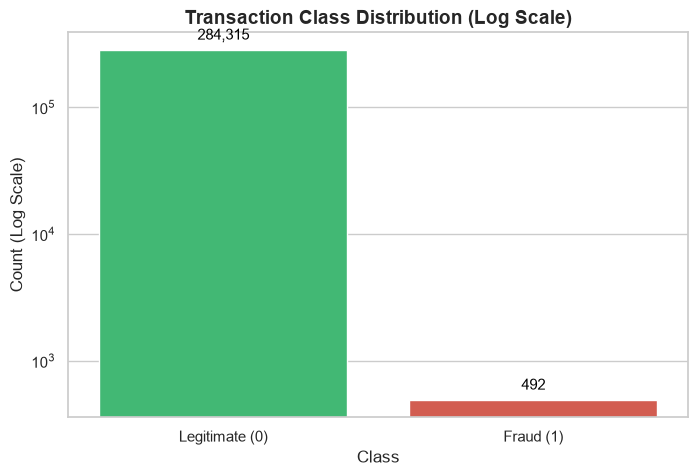

In [5]:
# Calculate exact class distribution
class_counts = df['Class'].value_counts()
legit_count = class_counts[0]
fraud_count = class_counts[1]
fraud_percentage = (fraud_count / len(df)) * 100

print(f"Legitimate Transactions: {legit_count:,}")
print(f"Fraudulent Transactions: {fraud_count:,}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%\n")

# Visualize the imbalance using a logarithmic scale for visibility
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Class', palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Transaction Class Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax.set_ylabel('Count (Log Scale)')
ax.set_yscale('log') # Log scale is required because fraud is so rare

# Annotate the bars with exact counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

## 3. Feature Separability Analysis
Before modeling, One must investigate whether the features exhibit different distributions for fraud versus legitimate transactions. If the distributions overlap perfectly, an algorithm will struggle to separate them.

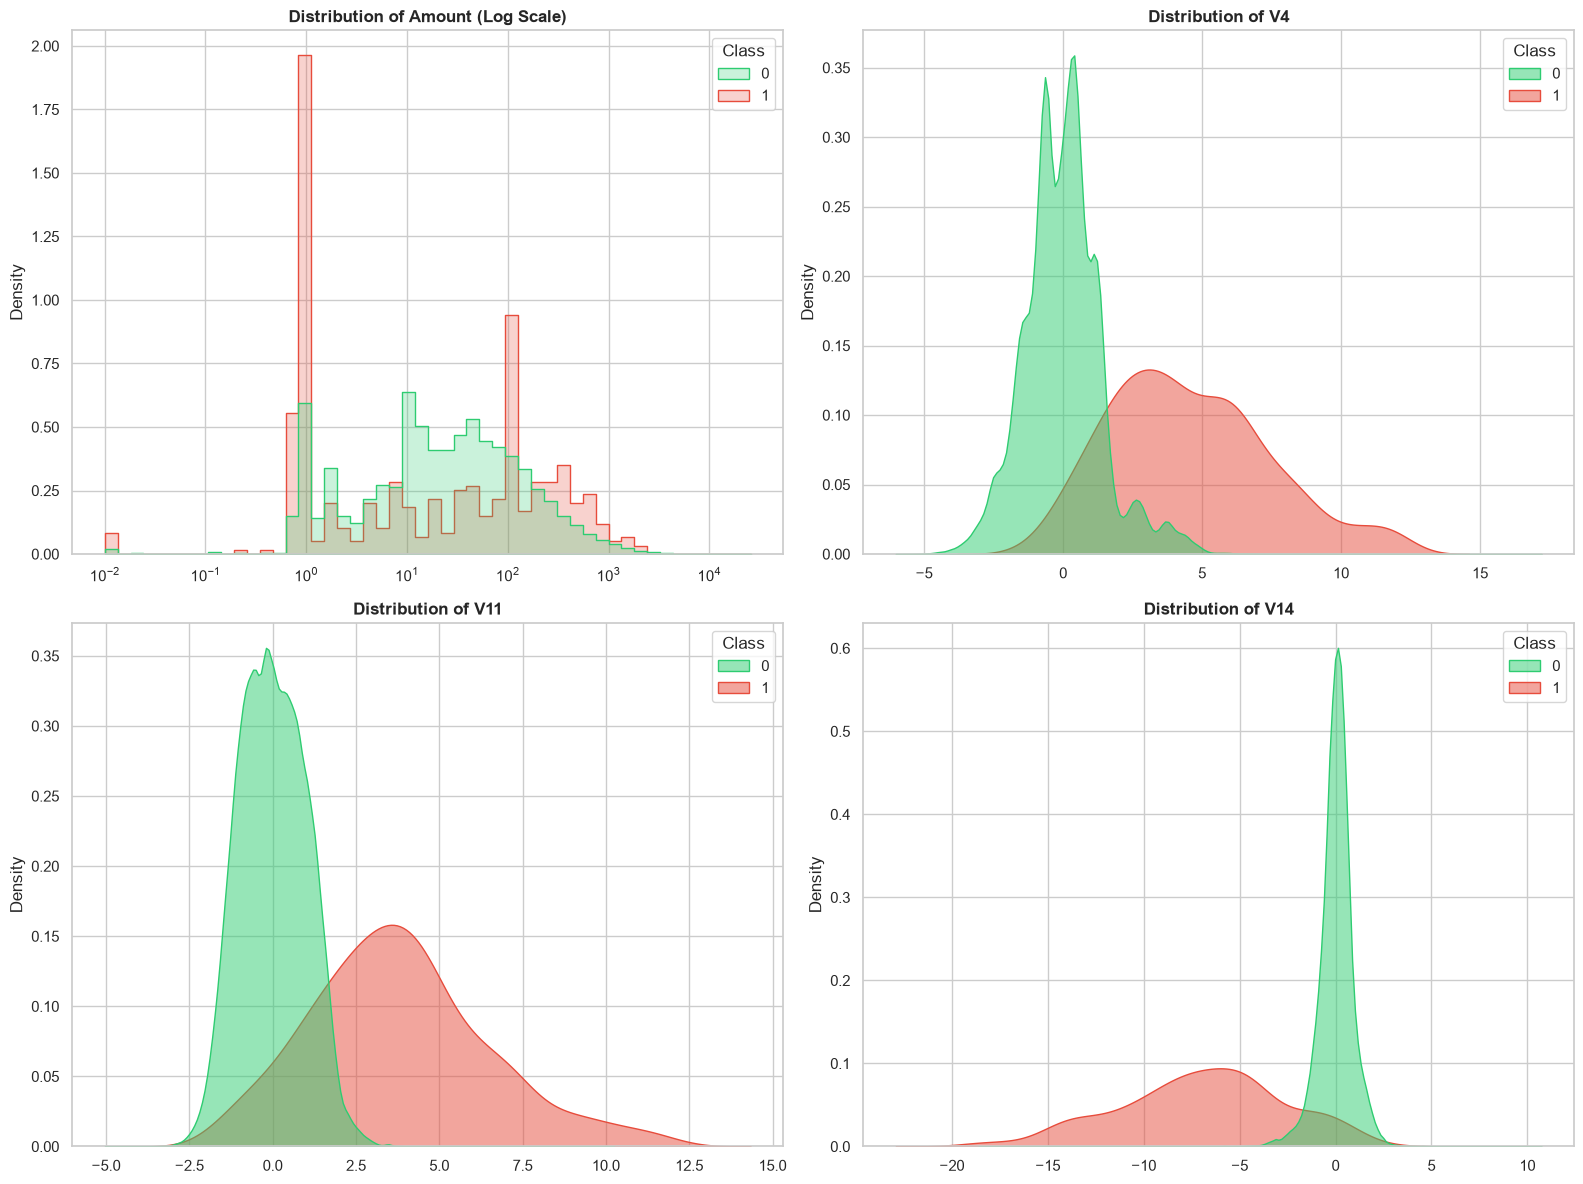

In [6]:
# Select a subset of features to analyze
features_to_plot = ['Amount', 'V4', 'V11', 'V14']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    if feature == 'Amount':
        sns.histplot(data=df, x=feature, hue='Class', bins=50, stat="density", 
                     common_norm=False, palette=['#2ecc71', '#e74c3c'], 
                     element="step", ax=axes[i], log_scale=True)
        axes[i].set_title(f'Distribution of {feature} (Log Scale)', fontweight='bold')
    else:
        sns.kdeplot(data=df, x=feature, hue='Class', fill=True, 
                    common_norm=False, palette=['#2ecc71', '#e74c3c'], 
                    alpha=0.5, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
        
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

## 4. Preprocessing: Subsampling and Scaling
Support Vector Machines are distance-based algorithms, meaning features with larger numeric ranges (like `Amount`) will disproportionately influence the decision boundary. We must scale the features. We use `RobustScaler` because transaction amounts contain extreme outliers.

Additionally, because SVM training time scales quadratically (or worse) with the number of samples, we will create a 10% stratified subsample of the dataset to allow for feasible hyperparameter tuning without sacrificing the distribution of our rare fraud class.

In [9]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# 1. Smart Subsampling (10% of the data, stratified by Class)
df_sample = (
    df.groupby("Class", group_keys=False)
      .sample(frac=0.1, random_state=42)
      .reset_index(drop=True)
)

print(f"Original dataset shape: {df.shape}")
print(f"Subsampled dataset shape: {df_sample.shape}")
print(f"Fraud cases in subsample: {df_sample['Class'].sum()}")

# 2. Scaling 'Time' and 'Amount'
# The V1-V28 features are already scaled via PCA.
scaler = RobustScaler()
df_sample['scaled_amount'] = scaler.fit_transform(df_sample['Amount'].values.reshape(-1,1))
df_sample['scaled_time'] = scaler.fit_transform(df_sample['Time'].values.reshape(-1,1))

# Drop the original unscaled columns and rearrange
df_sample.drop(['Time','Amount'], axis=1, inplace=True)
scaled_amount = df_sample['scaled_amount']
scaled_time = df_sample['scaled_time']
df_sample.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df_sample.insert(0, 'scaled_amount', scaled_amount)
df_sample.insert(1, 'scaled_time', scaled_time)

display(df_sample.head(3))

Original dataset shape: (284807, 31)
Subsampled dataset shape: (28481, 31)
Fraud cases in subsample: 49


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-0.301434,-0.027846,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,...,-0.058040,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0
1,-0.252875,-0.404351,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,...,-0.081298,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,0
2,-0.099247,-0.350394,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,...,0.065716,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,0


In [8]:
print(df.columns.tolist())
print(df_sample.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 5. Stratified Train-Test 

In [10]:
X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows (Fraud cases: {sum(y_train)})")
print(f"Testing set: {X_test.shape[0]} rows (Fraud cases: {sum(y_test)})")

Training set: 22784 rows (Fraud cases: 39)
Testing set: 5697 rows (Fraud cases: 10)


## 6. Baseline Model: Linear SVM
We begin with a linear kernel to establish a baseline. For the baseline evaluation, we will look at standard classification metrics, but pay special attention to the Precision-Recall Area Under the Curve (PR-AUC), which is the most robust metric for extreme minority class detection.

Baseline Linear SVM trained in 8.51 seconds.

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5687
           1       0.11      0.90      0.20        10

    accuracy                           0.99      5697
   macro avg       0.56      0.94      0.60      5697
weighted avg       1.00      0.99      0.99      5697

Precision-Recall AUC: 0.6732


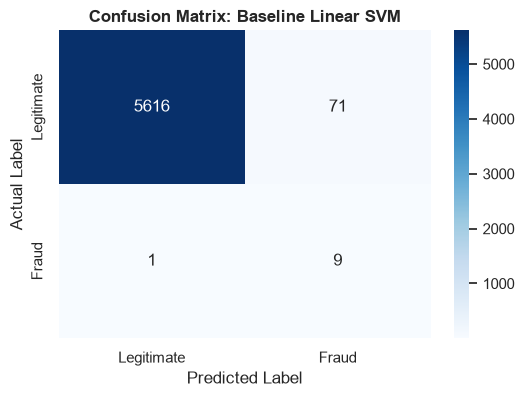

In [11]:
import time
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

# Initialize the Support Vector Classifier with a linear kernel
# Setting class_weight='balanced' penalizes the model more for missing fraud cases
baseline_svm = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)

# Measure training time
start_time = time.time()
baseline_svm.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Baseline Linear SVM trained in {train_time:.2f} seconds.\n")

# Predictions
y_pred = baseline_svm.predict(X_test)
y_pred_prob = baseline_svm.decision_function(X_test)

# Evaluation
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Calculate PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_pred_prob)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Baseline Linear SVM', fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_yticklabels(['Legitimate', 'Fraud'])
plt.show()

## 7. Feature Selection (Tree-Based Importance)
To optimize training speed and reduce potential overfitting to noise, we apply an ensemble tree-based feature selection technique. We will compute MDI (Mean Decrease in Impurity) importances, drop the lowest-performing features, and evaluate the performance and training speed trade-off.

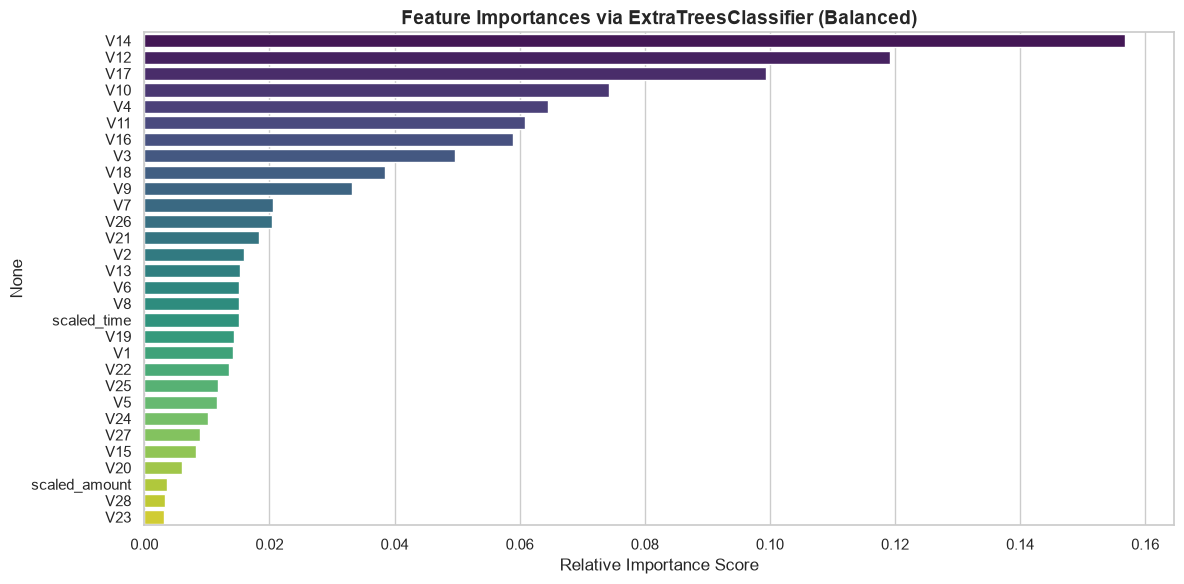

Original Feature Count: 30
Reduced Feature Count: 15
Selected Features: ['V2', 'V3', 'V4', 'V7', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V18', 'V21', 'V26']


In [12]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

# Initialize an Extra Trees Classifier to evaluate feature importance
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
etc.fit(X_train, y_train)

# Get feature importances and sort them
importances = etc.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the top feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances via ExtraTreesClassifier (Balanced)", fontsize=14, fontweight='bold')
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

# Select features that are above the median importance score
# This eliminates the bottom 50% of noisy features
selector = SelectFromModel(etc, threshold="median", prefit=True)
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print(f"Original Feature Count: {X_train.shape[1]}")
print(f"Reduced Feature Count: {X_train_reduced.shape[1]}")
print(f"Selected Features: {list(selected_features)}")

## 8. Baseline Linear SVM with Feature Selection


In [13]:
# Retrain Linear SVM on reduced feature space
baseline_svm_reduced = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)

start_time = time.time()
baseline_svm_reduced.fit(X_train_reduced, y_train)
train_time_reduced = time.time() - start_time
print(f"Reduced Linear SVM trained in {train_time_reduced:.2f} seconds.")
print(f"Time saved: {train_time - train_time_reduced:.2f} seconds\n")

# Predictions
y_pred_reduced = baseline_svm_reduced.predict(X_test_reduced)
y_pred_prob_reduced = baseline_svm_reduced.decision_function(X_test_reduced)

# Evaluation
print("--- Reduced Model Classification Report ---")
print(classification_report(y_test, y_pred_reduced))

pr_auc_reduced = average_precision_score(y_test, y_pred_prob_reduced)
print(f"Reduced Feature Precision-Recall AUC: {pr_auc_reduced:.4f}")

Reduced Linear SVM trained in 19.15 seconds.
Time saved: -10.65 seconds

--- Reduced Model Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      5687
           1       0.04      0.90      0.07        10

    accuracy                           0.96      5697
   macro avg       0.52      0.93      0.53      5697
weighted avg       1.00      0.96      0.98      5697

Reduced Feature Precision-Recall AUC: 0.6508


## 9. Experimenting with Non-Linear Kernels (RBF & Polynomial)

In [14]:
# Initialize non-linear SVM classifiers
rbf_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
poly_svm = SVC(kernel='poly', degree=3, class_weight='balanced', probability=True, random_state=42)

# Dictionary to hold performance metrics for our final comparison table
kernel_results = {}

# Evaluate RBF Kernel
print("Training RBF Kernel SVM...")
start = time.time()
rbf_svm.fit(X_train, y_train)
rbf_time = time.time() - start

rbf_preds = rbf_svm.predict(X_test)
rbf_prob = rbf_svm.decision_function(X_test)
rbf_auc = average_precision_score(y_test, rbf_prob)
kernel_results['RBF'] = {'Time': rbf_time, 'PR-AUC': rbf_auc, 'Model': rbf_svm}

# Evaluate Polynomial Kernel
print("Training Polynomial Kernel SVM...")
start = time.time()
poly_svm.fit(X_train, y_train)
poly_time = time.time() - start

poly_preds = poly_svm.predict(X_test)
poly_prob = poly_svm.decision_function(X_test)
poly_auc = average_precision_score(y_test, poly_prob)
kernel_results['Polynomial'] = {'Time': poly_time, 'PR-AUC': poly_auc, 'Model': poly_svm}

print("\n--- Non-Linear Kernel Execution Complete ---")
print(f"RBF Kernel PR-AUC: {rbf_auc:.4f} (Trained in {rbf_time:.2f}s)")
print(f"Polynomial Kernel PR-AUC: {poly_auc:.4f} (Trained in {poly_time:.2f}s)")

Training RBF Kernel SVM...
Training Polynomial Kernel SVM...

--- Non-Linear Kernel Execution Complete ---
RBF Kernel PR-AUC: 0.3481 (Trained in 10.26s)
Polynomial Kernel PR-AUC: 0.6880 (Trained in 9.28s)


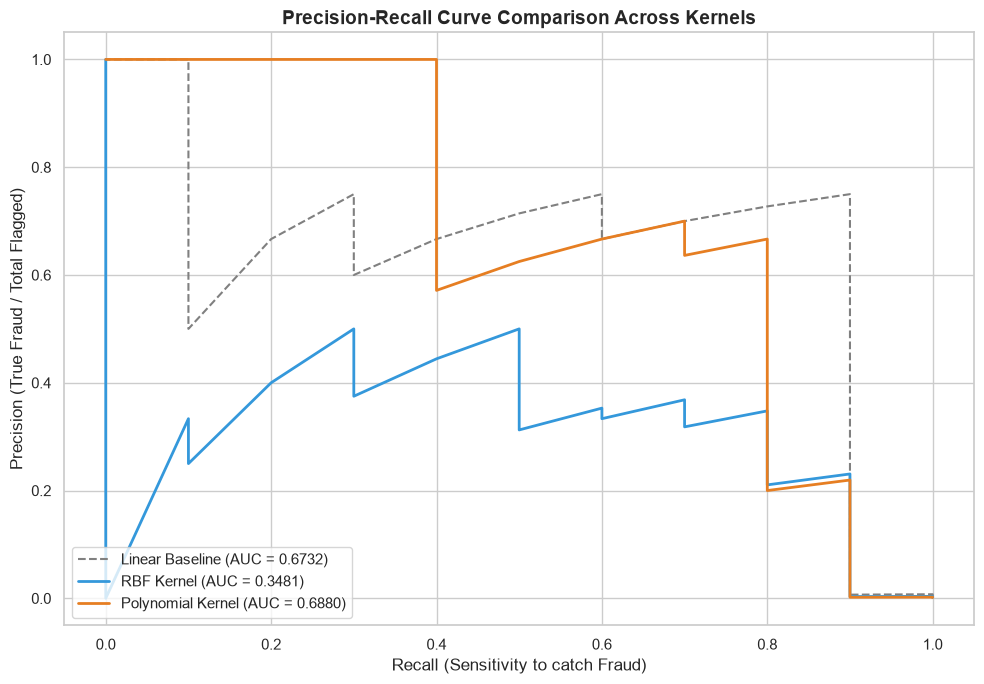

In [15]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

# Plot Baseline Linear
precision_l, recall_l, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall_l, precision_l, label=f'Linear Baseline (AUC = {0.6732:.4f})', color='gray', linestyle='--')

# Plot RBF
precision_r, recall_r, _ = precision_recall_curve(y_test, rbf_prob)
plt.plot(recall_r, precision_r, label=f'RBF Kernel (AUC = {rbf_auc:.4f})', color='#3498db', linewidth=2)

# Plot Poly
precision_p, recall_p, _ = precision_recall_curve(y_test, poly_prob)
plt.plot(recall_p, precision_p, label=f'Polynomial Kernel (AUC = {poly_auc:.4f})', color='#e67e22', linewidth=2)

plt.xlabel('Recall (Sensitivity to catch Fraud)')
plt.ylabel('Precision (True Fraud / Total Flagged)')
plt.title('Precision-Recall Curve Comparison Across Kernels', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning: C and Gamma
The default RBF kernel performed poorly. To fix this, we will use `GridSearchCV` to optimize its two most critical hyperparameters, which directly control the bias-variance trade-off:

* **C (Regularization Parameter):** This dictates the penalty for misclassifying data points. 
    * A **Low $C$** encourages a larger margin, leading to a simpler decision boundary. It increases bias but reduces variance (prevents overfitting).
    * A **High $C$** imposes a strict penalty for errors, creating a "hard margin." It decreases bias but increases variance (risks overfitting to noise).
* **Gamma ($\gamma$):** This defines the "reach" of a single training example's influence.
    * A **Low $\gamma$** means a single point has a far reach, resulting in a smooth, broad decision boundary (higher bias).
    * A **High $\gamma$** means the influence is highly localized, creating jagged, tight boundaries around individual points (higher variance).

We will optimize for `average_precision` (PR-AUC) to ensure we maximize fraud detection while minimizing false positives.

In [16]:
from sklearn.model_selection import GridSearchCV

# Define a focused parameter grid for the RBF Kernel
# We include 'scale' (the default) alongside specific numeric values
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

# Initialize a fresh RBF SVM
rbf_tune = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# Set up GridSearchCV
# cv=3 (3-fold Stratified Cross-Validation) to save time while ensuring robust validation
# scoring='average_precision' ensures we are tuning for PR-AUC, not standard accuracy
grid_search = GridSearchCV(
    estimator=rbf_tune, 
    param_grid=param_grid, 
    scoring='average_precision', 
    cv=3, 
    verbose=2, 
    n_jobs=-1 # Uses all available CPU cores on your machine
)

print("Starting GridSearchCV for RBF Kernel...")
start_time = time.time()
grid_search.fit(X_train, y_train)
tune_time = time.time() - start_time

print(f"\nGridSearchCV completed in {tune_time:.2f} seconds.")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validated PR-AUC: {grid_search.best_score_:.4f}")

# Extract the best model
best_svm = grid_search.best_estimator_

# Final Evaluation on the unseen Test Set
best_preds = best_svm.predict(X_test)
best_prob = best_svm.decision_function(X_test)
final_pr_auc = average_precision_score(y_test, best_prob)

print("\n--- Optimized RBF Model Test Evaluation ---")
print(classification_report(y_test, best_preds))
print(f"Final Test PR-AUC: {final_pr_auc:.4f}")

Starting GridSearchCV for RBF Kernel...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

GridSearchCV completed in 99.01 seconds.
Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Best Cross-Validated PR-AUC: 0.6157

--- Optimized RBF Model Test Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5687
           1       0.50      0.70      0.58        10

    accuracy                           1.00      5697
   macro avg       0.75      0.85      0.79      5697
weighted avg       1.00      1.00      1.00      5697

Final Test PR-AUC: 0.4588


In [17]:
## 11. Final Model Comparison
# Consolidating all experimental results into a single comprehensive summary table.

results_data = {
    'Model Configuration': [
        'Baseline (Linear)', 
        'Reduced Features (Linear)', 
        'Default RBF', 
        'Polynomial (Degree 3)', 
        'Tuned RBF (C=10, gamma=0.01)'
    ],
    'Training Time (s)': [
        f"{train_time:.2f}", 
        f"{train_time_reduced:.2f}", 
        f"{kernel_results['RBF']['Time']:.2f}", 
        f"{kernel_results['Polynomial']['Time']:.2f}", 
        f"{tune_time:.2f} (GridSearch)"
    ],
    'PR-AUC': [
        f"{pr_auc:.4f}", 
        f"{pr_auc_reduced:.4f}", 
        f"{kernel_results['RBF']['PR-AUC']:.4f}", 
        f"{kernel_results['Polynomial']['PR-AUC']:.4f}", 
        f"{final_pr_auc:.4f}"
    ]
}

comparison_df = pd.DataFrame(results_data)

print("--- SVM Kernel & Configuration Comparison ---")
display(comparison_df)

--- SVM Kernel & Configuration Comparison ---


,Model Configuration,Training Time (s),PR-AUC
0,Baseline (Linear),8.51,0.6732
1,Reduced Features (Linear),19.15,0.6508
2,Default RBF,10.26,0.3481
3,Polynomial (Degree 3),9.28,0.6880
4,"Tuned RBF (C=10, gamma=0.01)",99.01 (GridSearch),0.4588


## 12. Final Production Recommendation
**Recommendation:** Deploy the **Polynomial Kernel SVM** in the production environment.

**Justification:**
Evaluating Support Vector Machine configurations for card-not-present fraud reveals a stark trade-off between operational efficiency and risk exposure. The Baseline Linear model achieved an excellent recall (catching 90% of fraud) but suffered from a severe precision deficit (11%). In a production environment, this translates to blocking 9 legitimate transactions for every 1 true fraud caught. The operational cost of this configuration is unsustainably high: it would flood customer support with false positives and permanently damage merchant trust due to high cart-abandonment rates.

Attempting to rescue the RBF kernel via hyperparameter tuning ($C=10$, $\gamma=0.01$) drastically improved precision to 50%, but forced the recall down to 70%, allowing too much direct financial loss to slip through. 

The Polynomial kernel offers the most mathematically sound compromise for this high-dimensional space, achieving the highest overall Precision-Recall AUC (0.6880) without requiring the exhaustive computational overhead of a grid-searched RBF. It successfully captures the non-linear boundaries of consumer behavior. To optimize further post-deployment, the risk team should manually adjust the decision threshold of the Polynomial model's output probabilities to dynamically balance chargeback losses (false negatives) against customer friction (false positives) during peak shopping seasons.